# Task 3: Viscoelasticity

Modellierung viskoelastischen Materialverhaltens mit Recurrent Neural Networks (RNNs).

**Maxwell-Element Parameter:** $\{E^\infty, E, \eta\} = \{0.5, 2, 1\}$

**Lastfälle:** $(A, \omega) \in \{(1,1), (1,2), (2,3)\}$

**Modelle:**
1. Simple RNN (naiv, ohne Physik)
2. Maxwell-Modell (analytisch + trainierbare Evolutionsgleichung)
3. GSM-Modell (Generalized Standard Materials)

# NUR FÜR ALEX WEGEN VENV UNTERSCHIED

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()

candidates = [
    cwd / "src",                          # if cwd == viscoelasticity/
    cwd / "viscoelasticity" / "src",      # if cwd == workspace root
]

src_path = next((p for p in candidates if p.exists()), None)

if src_path is None:
    raise FileNotFoundError(
        "Could not find the 'src' directory. Tried:\n" +
        "\n".join(str(p) for p in candidates) +
        f"\nCurrent working directory is: {cwd}"
    )

sys.path.insert(0, str(src_path))
print("Added to sys.path:", src_path)


Added to sys.path: C:\Users\alexp\Desktop\#Uni\Master 1\5. Semester\PAML Tutorium\Repo\ML-Tutorial-WS25_26\viscoelasticity\src


In [2]:
import jax
import jax.numpy as jnp
import jax.random as jrandom
import klax
import numpy as np
import time
import matplotlib.pyplot as plt

import tmlsm.data as td
import tmlsm.plots as tp
import tmlsm.models as tm
from tmlsm import evaluation as ev

In [3]:
# Material parameters
E_infty = 0.5
E = 2.0
eta = 1.0
n = 100  # time steps per period

## Datengenerierung & Visualisierung

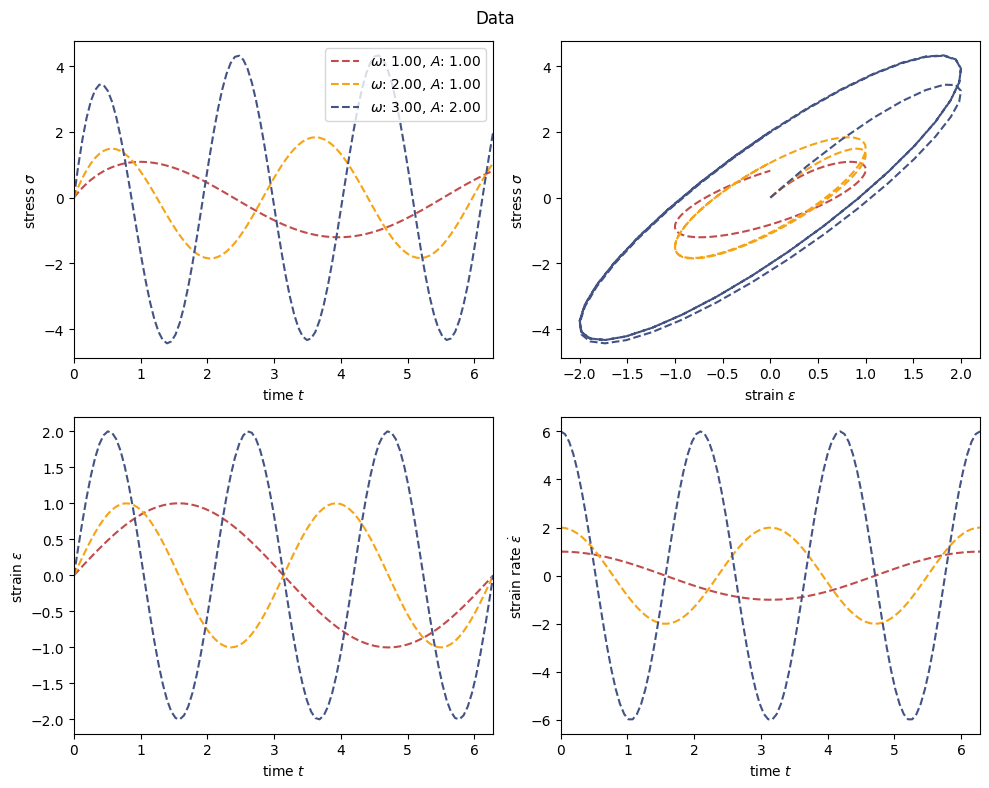

In [32]:
# All load cases
omegas_all = [1, 2, 3]
As_all = [1, 1, 2]

eps_all, eps_dot_all, sig_all, dts_all = td.generate_data_harmonic(
    E_infty, E, eta, n, omegas_all, As_all
)
tp.plot_data(eps_all, eps_dot_all, sig_all, omegas_all, As_all)

In [ ]:
# Relaxation data
eps_relax, eps_dot_relax, sig_relax, dts_relax = td.generate_data_relaxation(
    E_infty, E, eta, n, omegas_all, As_all
)
tp.plot_data(eps_relax, eps_dot_relax, sig_relax, omegas_all, As_all)

## Modell 1: Simple RNN

Naiver RNN ohne physikalische Informationen. Das Netzwerk lernt direkt die Abbildung
$(\gamma_\text{old}, \varepsilon, \Delta t) \to (\gamma_\text{new}, \sigma)$.

#### Simple RNN Loadpath Sweep

In [ ]:
from tmlsm.run_rnn_experiments import run_all_experiments
run_all_experiments()

In [ ]:
rnn_dirs = ["artifacts/rnn_experiments"]

# for config in ["omega_1", "omega_2", "omega_3", "omega_4", "amp_2", "amp_3", "amp_4", "mixed_2", "mixed_4"]:
#     tp.plot_latest(config, seeds=[0,1,2,3,4], steps=250000, test_loadcases=[(5,5)], search_dirs=rnn_dirs)
    
tp.plot_latest("mixed_4", seeds=[0,1,2,3,4], steps=250000, test_loadcases=[(6,6)], search_dirs=rnn_dirs)

In [ ]:
# Heatmap Plots harmonic unnormalized + noise
tp.plot_heatmaps(["omega_4", "amp_4", "mixed_4"], test_type="harmonic", normalize=True, log=True, test_omegas=list(np.arange(0.5, 6.5, 0.5)), test_As=list(np.arange(0.5, 6.5, 0.5)), noise_std_rel=0.02, model_type="simple_rnn")
# Heatmap Plots normalized
tp.plot_heatmaps(["omega_4", "amp_4", "mixed_4"], test_type="harmonic", normalize=True, log=True, test_omegas=list(np.arange(0.5, 10.5, 0.5)), test_As=list(np.arange(0.5, 10.5, 0.5)), model_type="simple_rnn")
# Heatmap Plots relaxation
tp.plot_heatmaps(["omega_4", "amp_4", "mixed_4"], test_type="relaxation", log=True, test_omegas=list(np.arange(0.5, 6.5, 0.5)), test_As=list(np.arange(0.5, 6.5, 0.5)), model_type="simple_rnn")

In [ ]:
tp. plot_best(["omega_4", "amp_4", "mixed_4"], steps=250000,noise_std_rel=0.0, test_loadcases=[(6,6)],n_test_timesteps=400 ,model_type="simple_rnn")

<>:13: SyntaxWarning: invalid escape sequence '\o'
<>:13: SyntaxWarning: invalid escape sequence '\o'
C:\Users\alexp\AppData\Local\Temp\ipykernel_5732\950219388.py:13: SyntaxWarning: invalid escape sequence '\o'
  legend_labels={"omega_4":"$\omega$-sweep",


Gefunden: artifacts\rnn_experiments\simple_rnn__omega_4__seed_1__250000steps__100ts__20260209_203830.eqx
Gefunden: artifacts\rnn_experiments\simple_rnn__amp_4__seed_0__250000steps__100ts__20260209_212957.eqx
Gefunden: artifacts\rnn_experiments\simple_rnn__mixed_4__seed_4__250000steps__100ts__20260209_221434.eqx


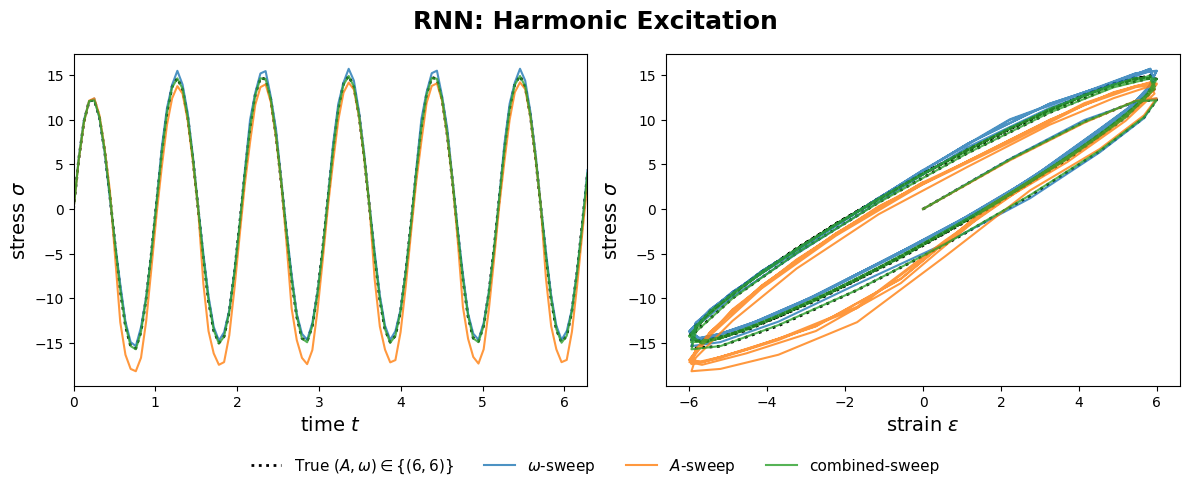

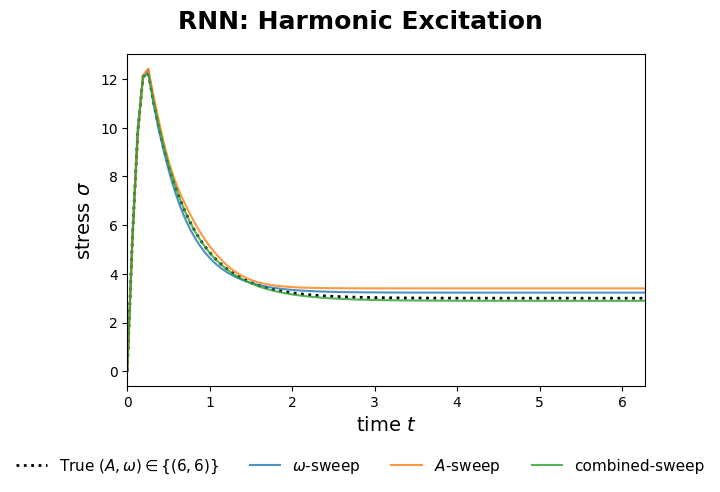

In [30]:
tp.plot_best(
    ["omega_4", "amp_4", "mixed_4"],
    model_type="simple_rnn",
    axis_labels_time=("time $t$", "stress $\\sigma$"),
    axis_labels_epssig=("strain $\\varepsilon$", "stress $\\sigma$"),
    title_fontsize=18,
    legend_fontsize=11,
    axis_label_fontsize=14,
    steps=250000,
    noise_std_rel=0.0,
    test_loadcases=[(6, 6)],
    n_test_timesteps=100,
    legend_labels={"omega_4":"$\omega$-sweep",
                   "amp_4":"$A$-sweep",
                   "mixed_4":"combined-sweep"},                 # dict: {config_name: "Pretty label"}
    title="RNN: Harmonic Excitation",
    relaxation_panels="left",
    title_bold=True,
    gt_label= r"True $(A,\omega)\in\{(6, 6)\}$",
    legend_position="below",
    show_legend=True,
    legend_bottom_margin=0.1
)


### Old

In [ ]:
# Calibration data: (A=1, omega=1)
omegas_cal = [1.0]
As_cal = [1.0]

eps_cal, eps_dot_cal, sig_cal, dts_cal = td.generate_data_harmonic(
    E_infty, E, eta, n, omegas_cal, As_cal
)
tp.plot_data(eps_cal, eps_dot_cal, sig_cal, omegas_cal, As_cal)

In [ ]:
# Build and train Simple RNN
key = jrandom.PRNGKey(time.time_ns())
keys = jrandom.split(key, 2)

model_rnn = tm.build(key=keys[0])

model_rnn, history_rnn = klax.fit(
    model_rnn,
    ((eps_cal, dts_cal), sig_cal),
    batch_axis=0,
    steps=20000,
    history=klax.HistoryCallback(log_every=100),
    key=keys[1],
)

history_rnn.plot()

In [ ]:
model_rnn_ = klax.finalize(model_rnn)

### Interpolation: Test auf Trainingsdaten

In [ ]:
sig_pred = jax.vmap(model_rnn_)((eps_cal, dts_cal))
tp.plot_model_pred(eps_cal, sig_cal, sig_pred, omegas_cal, As_cal)

In [ ]:
# Test on all harmonic load cases
omegas_test = [1, 2, 3, 2]
As_test = [1, 1, 2, 3]

eps_test, eps_dot_test, sig_test, dts_test = td.generate_data_harmonic(
    E_infty, E, eta, n, omegas_test, As_test
)
sig_pred_test = jax.vmap(model_rnn_)((eps_test, dts_test))
tp.plot_model_pred(eps_test, sig_test, sig_pred_test, omegas_test, As_test)

In [ ]:
# Test on relaxation
eps_relax_test, eps_dot_relax_test, sig_relax_test, dts_relax_test = td.generate_data_relaxation(
    E_infty, E, eta, n, omegas_test, As_test
)
sig_pred_relax = jax.vmap(model_rnn_)((eps_relax_test, dts_relax_test))
tp.plot_model_pred(eps_relax_test, sig_relax_test, sig_pred_relax, omegas_test, As_test)

### Extrapolation: Test auf neue Lastfälle

---
## Modell 2: Maxwell-Modell

### 2a) Analytisches Maxwell-Modell (nicht trainierbar)

Feste Gleichungen:
- $e(\varepsilon, \gamma) = \frac{1}{2} E^\infty \varepsilon^2 + \frac{1}{2} E (\varepsilon - \gamma)^2$
- $\sigma = E^\infty \varepsilon + E(\varepsilon - \gamma)$
- $\dot{\gamma} = \frac{E}{\eta}(\varepsilon - \gamma)$

In [ ]:
# Calibration data: (A=1, omega=1)
omegas_cal = [1.0]
As_cal = [1.0]

eps_cal, eps_dot_cal, sig_cal, dts_cal = td.generate_data_harmonic(
    E_infty, E, eta, n, omegas_cal, As_cal
)

In [ ]:
# Test on all harmonic load cases
#omegas_test = [1, 2, 3, 4, 5]
omegas_test = [3, 4, 5]
#As_test = [1, 1, 2, 3, 4]
As_test = [2, 3, 4]

eps_test, eps_dot_test, sig_test, dts_test = td.generate_data_harmonic(
    E_infty, E, eta, n, omegas_test, As_test
)

# Test on relaxation
eps_relax_test, eps_dot_relax_test, sig_relax_test, dts_relax_test = td.generate_data_relaxation(
    E_infty, E, eta, n, omegas_test, As_test
)

In [ ]:
# Analytical Maxwell model (no training needed)
model_maxwell = tm.build_maxwell(E_infty=E_infty, E_val=E, eta=eta)

# Test on calibration data
sig_maxwell_cal = jax.vmap(model_maxwell)((eps_cal, dts_cal))
tp.plot_model_pred(eps_cal, sig_cal, sig_maxwell_cal, omegas_cal, As_cal)

In [ ]:
# Test on all load cases + relaxation
sig_maxwell_all = jax.vmap(model_maxwell)((eps_test, dts_test))
tp.plot_model_pred(eps_test, sig_test, sig_maxwell_all, omegas_test, As_test)

sig_maxwell_relax = jax.vmap(model_maxwell)((eps_relax_test, dts_relax_test))
tp.plot_model_pred(eps_relax_test, sig_relax_test, sig_maxwell_relax, omegas_test, As_test)

### 2b) Maxwell-Modell mit NN Evolutionsgleichung

In [ ]:
from tmlsm.run_maxwell_nn_experiments import run_all_experiments
run_all_experiments()

In [ ]:
maxwell_dirs = ["artifacts/maxwell_nn_experiments"]

tp.plot_latest("omega_4", seeds=[0,1,2,3,4], steps=100000, test_loadcases=[(6,6)], search_dirs=maxwell_dirs)

In [ ]:
# 1. Heatmap harmonic normalized (ohne noise)
tp.plot_heatmaps(["omega_4", "amp_4", "mixed_4"], test_type="harmonic", normalize=True, log=True, test_omegas=list(np.arange(0.5, 16.5, 0.5)), test_As=list(np.arange(0.5, 16.5, 0.5)), model_type="maxwell_nn", steps=100000)

# 2. Heatmap harmonic normalized + noise
tp.plot_heatmaps(["omega_4", "amp_4", "mixed_4"], test_type="harmonic", normalize=True, log=True, test_omegas=list(np.arange(0.5, 16.5, 0.5)), test_As=list(np.arange(0.5, 16.5, 0.5)), noise_std_rel=0.02, model_type="maxwell_nn", steps=100000)

# 3. Heatmap relaxation
tp.plot_heatmaps(["omega_4", "amp_4", "mixed_4"], test_type="relaxation", log=True, test_omegas=list(np.arange(0.5, 16.5, 0.5)), test_As=list(np.arange(0.5, 16.5, 0.5)), model_type="maxwell_nn", steps=100000)

Gefunden: artifacts\maxwell_nn_experiments\maxwell_nn__mixed_4__seed_3__100000steps__100ts__20260210_194741.eqx


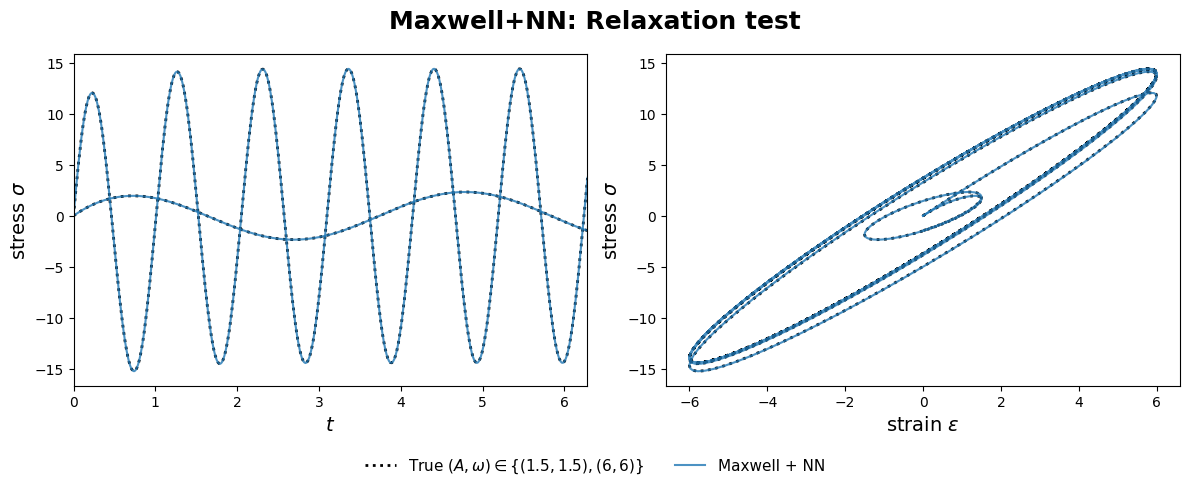

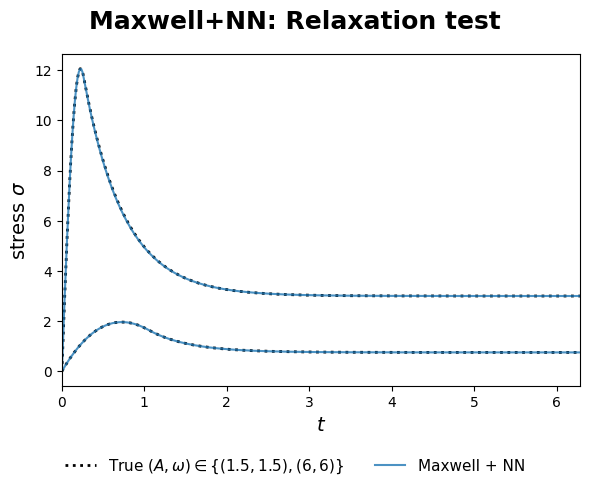

In [31]:
tp.plot_best(
    ["mixed_4"],
    model_type="maxwell_nn",
    axis_labels_time=("$t$", "stress $\\sigma$"),
    axis_labels_epssig=("strain $\\varepsilon$", "stress $\\sigma$"),
    title_fontsize=18,
    legend_fontsize=11,
    axis_label_fontsize=14,
    steps=100000,
    noise_std_rel=0.0,
    test_loadcases=[(1.5, 1.5),(6,6)],
    n_test_timesteps=400,
    legend_labels={"mixed_4":"Maxwell + NN"},                 # dict: {config_name: "Pretty label"}
    title="Maxwell+NN: Relaxation test",
    relaxation_panels="left",
    title_bold=True,
    gt_label= r"True $(A,\omega)\in\{(1.5,1.5),(6,6)\}$",
    legend_position="below",
    show_legend=True,
    legend_bottom_margin=0.1
)


In [ ]:
tp.plot_best(["mixed_4"], steps=100000,noise_std_rel=0.0, test_loadcases=[(1.5,1.5),(6,6)], model_type="maxwell_nn", n_test_timesteps=200)

#### Old

In [ ]:
# Calibration data: (A=1, omega=1)
omegas_cal = [1.0, 1.0]
As_cal = [1.0, 2.0]
n=50
eps_cal, eps_dot_cal, sig_cal, dts_cal = td.generate_data_harmonic(
    E_infty, E, eta, n ,omegas_cal, As_cal
)

In [ ]:
# Build and train Maxwell model with NN evolution equation
key = jrandom.PRNGKey(time.time_ns())
keys = jrandom.split(key, 2)

model_mnn = tm.build_maxwell_nn(key=keys[0], E_infty=E_infty, E_val=E)

model_mnn, history_mnn = klax.fit(
    model_mnn,
    ((eps_cal, dts_cal), sig_cal),
    batch_axis=0,
    steps=50000,
    history=klax.HistoryCallback(log_every=500),
    key=keys[1],
)

history_mnn.plot()

In [ ]:
# Test on all harmonic load cases
omegas_test = [1.5, 6]
As_test = [1.5, 6]
n=600
eps_test, eps_dot_test, sig_test, dts_test = td.generate_data_harmonic(
    E_infty, E, eta, n, omegas_test, As_test
)

# Test on relaxation
eps_relax_test, eps_dot_relax_test, sig_relax_test, dts_relax_test = td.generate_data_relaxation(
    E_infty, E, eta, n, omegas_test, As_test
)

In [ ]:
model_mnn_ = klax.finalize(model_mnn)

# Interpolation
sig_mnn_cal = jax.vmap(model_mnn_)((eps_cal, dts_cal))
tp.plot_model_pred(eps_cal, sig_cal, sig_mnn_cal, omegas_cal, As_cal)

# Extrapolation
sig_mnn_test = jax.vmap(model_mnn_)((eps_test, dts_test))
tp.plot_model_pred(eps_test, sig_test, sig_mnn_test, omegas_test, As_test)

# Relaxation
sig_mnn_relax = jax.vmap(model_mnn_)((eps_relax_test, dts_relax_test))
tp.plot_model_pred(eps_relax_test, sig_relax_test, sig_mnn_relax, omegas_test, As_test)

#### Plotting FFNN output vs true constant

In [ ]:
case = 0

gamma_full, sig_hist, f_hist = ev.maxwell_nn_coeff_series(
    model_mnn_, eps_test[case], dts_test[case]
)

T = eps_test.shape[1]
ts = np.linspace(0, 2*np.pi, T)   # harmonic visualization axis
true_const = E / eta              # your cached scalars

plt.figure(figsize=(10, 3))
plt.plot(ts, f_hist, label="FFNN coefficient $f_\\theta(\\epsilon,\\gamma)$")
plt.axhline(true_const, linestyle="--", label=f"true $E/\\eta$ = {true_const:.4g}")
plt.xlabel("t")
plt.ylabel("coefficient")
plt.title(f"Maxwell+NN coefficient vs true constant (case {case})")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

#### Testing with noisy test data

In [ ]:
eps_test_noisy, eps_dot_test_noisy, sig_test, dts_test = td.generate_data_harmonic_noisy_eps(
    E_infty, E, eta, n, omegas_test, As_test,
    noise_std_rel=0.02,      # e.g. 2% of amplitude per case
    seed=0,
    recompute_eps_dot_from_noisy=False,  # True if any model uses eps_dot
)

In [ ]:
eps_relax_noisy, eps_dot_relax_noisy, sig_relax_true, dts_relax = td.generate_data_relaxation_noisy_eps(
    E_infty, E, eta, n, omegas_test, As_test,
    noise_std_rel=0.02,  # 2% amplitude noise
    seed=0,
    recompute_eps_dot_from_noisy=False,  # Maxwell+NN uses (eps, dt) so keep False
)

In [ ]:
# Extrapolation
sig_mnn_test = jax.vmap(model_mnn_)((eps_test_noisy, dts_test))
tp.plot_model_pred(eps_test_noisy, sig_test, sig_mnn_test, omegas_test, As_test)

# Relaxation
sig_mnn_relax_noisy = jax.vmap(model_mnn_)((eps_relax_noisy, dts_relax))
tp.plot_model_pred(eps_relax_noisy, sig_relax_true, sig_mnn_relax_noisy, omegas_test, As_test)

In [ ]:
case = 0

gamma_full, sig_hist, f_hist = ev.maxwell_nn_coeff_series(
    model_mnn_, eps_test_noisy[case], dts_test[case]
)

T = eps_test_noisy.shape[1]
ts = np.linspace(0, 2*np.pi, T)   # harmonic visualization axis
true_const = E / eta              # your cached scalars

plt.figure(figsize=(10, 3))
plt.plot(ts, f_hist, label="FFNN coefficient $f_\\theta(\\epsilon,\\gamma)$")
plt.axhline(true_const, linestyle="--", label=f"true $E/\\eta$ = {true_const:.4g}")
plt.xlabel("t")
plt.ylabel("coefficient")
plt.title(f"Maxwell+NN coefficient vs true constant (case {case})")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

---
## Modell 3: GSM-Modell (Generalized Standard Materials)

- $e = e(\varepsilon, \gamma)$ durch FFNN
- $\sigma = \frac{\partial e}{\partial \varepsilon}$
- $\dot{\gamma} = -g \cdot \frac{\partial e}{\partial \gamma}$, mit $g = \eta^{-1} = 1$

#### Extensive GSM Loadpath Sweep

In [ ]:
from tmlsm.run_gsm_experiments import run_all_experiments
run_all_experiments()

### Evaluate Impact of Initializations

In [ ]:
for config in ["omega_1", "omega_2", "omega_3", "omega_4", "amp_2", "amp_3", "amp_4", "mixed_2", "mixed_4"]:
    tp.plot_latest(config, seeds=[0,1,2,3,4], steps=250000, test_loadcases=[(10,10)]) #, (2,5), (6,6)

### Heatmaps for Testcase Variation

In [ ]:
# Heatmap Plots harmonic unnormalized
tp.plot_heatmaps(["omega_4", "amp_4", "mixed_4"], test_type="harmonic", log=True, test_omegas=list(np.arange(0.5, 6.5, 0.5)), test_As=list(np.arange(0.5, 6.5, 0.5)), n_test_timesteps=100)
tp.plot_heatmaps(["omega_4", "amp_4", "mixed_4"], test_type="harmonic", log=True, test_omegas=list(np.arange(0.5, 6.5, 0.5)), test_As=list(np.arange(0.5, 6.5, 0.5)), n_test_timesteps=400)

In [ ]:
# Heatmap Plots harmonic unnormalized
tp.plot_heatmaps(["omega_4", "amp_4", "mixed_4"], test_type="harmonic", normalize=True, log=True, test_omegas=list(np.arange(0.5, 6.5, 0.5)), test_As=list(np.arange(0.5, 6.5, 0.5)), noise_std_rel=0.02)

In [ ]:
# Heatmap Plots normalized
tp.plot_heatmaps(["omega_4", "amp_4", "mixed_4"], test_type="harmonic",normalize=True, log=True, test_omegas=list(np.arange(0.5, 6.5, 0.5)), test_As=list(np.arange(0.5, 6.5, 0.5)))

In [ ]:
# Heatmap Plots relaxation
tp.plot_heatmaps(["omega_4", "amp_4", "mixed_4"], test_type="relaxation", log=True, test_omegas=list(np.arange(0.5, 6.5, 0.5)), test_As=list(np.arange(0.5, 6.5, 0.5)))

### Evaluate Best Seed comparison

In [ ]:
tp.plot_best(["omega_4", "amp_4", "mixed_4"], steps=250000,noise_std_rel=0.0, test_loadcases=[(6,6)],n_test_timesteps=400)
tp.plot_best(["omega_4", "amp_4", "mixed_4"], steps=250000,noise_std_rel=0.0, test_loadcases=[(6,6)],n_test_timesteps=100)

<>:13: SyntaxWarning: invalid escape sequence '\o'
<>:13: SyntaxWarning: invalid escape sequence '\o'
C:\Users\alexp\AppData\Local\Temp\ipykernel_5732\2106917603.py:13: SyntaxWarning: invalid escape sequence '\o'
  legend_labels={"omega_4":"$\omega$-sweep",


Gefunden: artifacts\gsm_experiments\gsm__omega_4__seed_1__250000steps__100ts__20260209_015015.eqx
Gefunden: artifacts\gsm_experiments\gsm__amp_4__seed_0__250000steps__100ts__20260209_032928.eqx
Gefunden: artifacts\gsm_experiments\gsm__mixed_4__seed_1__250000steps__100ts__20260209_042947.eqx


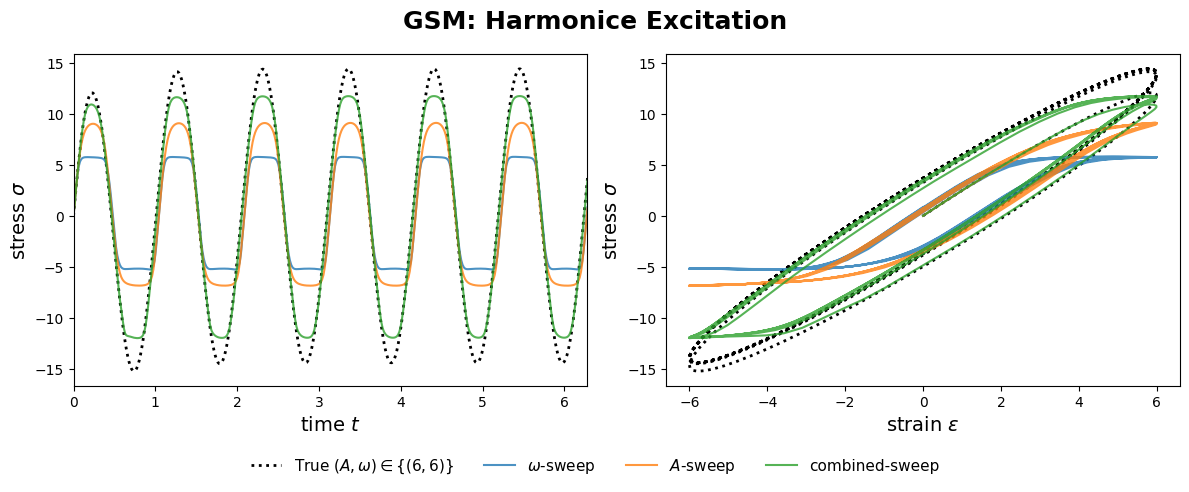

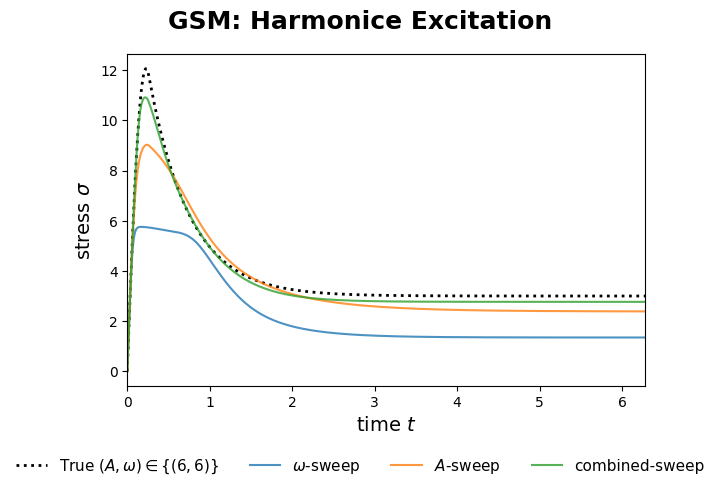

In [24]:
tp.plot_best(
    ["omega_4", "amp_4", "mixed_4"],
    model_type="gsm",
    axis_labels_time=("time $t$", "stress $\\sigma$"),
    axis_labels_epssig=("strain $\\varepsilon$", "stress $\\sigma$"),
    title_fontsize=18,
    legend_fontsize=11,
    axis_label_fontsize=14,
    steps=250000,
    noise_std_rel=0.0,
    test_loadcases=[(6, 6)],
    n_test_timesteps=400,
    legend_labels={"omega_4":"$\omega$-sweep",
                   "amp_4":"$A$-sweep",
                   "mixed_4":"combined-sweep"},                 # dict: {config_name: "Pretty label"}
    title="GSM: Harmonice Excitation",
    relaxation_panels="left",
    title_bold=True,
    gt_label= r"True $(A,\omega)\in\{(6, 6)\}$",
    legend_position="below",
    show_legend=True,
    legend_bottom_margin=0.1
)


### Evaluate $\gamma$ dynamics of GSM

In [ ]:
tp.plot_best_gamma(
    ["omega_4", "amp_4", "mixed_4"],
    steps=250000,
    noise_std_rel=0.0,
    test_loadcases=[(6, 6)],
    n_test_timesteps=100
)


### Apply "teacher forcing $\gamma$" test (using ground truth gamma to evaluate trained GSM)

In [ ]:
tp.plot_best_teacher_forced(
    ["mixed_4"],
    steps=250000,
    noise_std_rel=0.0,
    test_loadcases=[(6, 6)],
    n_test_timesteps=100
)

### Evaluate $\gamma$ dynamics of GSM

In [ ]:
tp.plot_best_gamma(
    ["omega_4", "amp_4", "mixed_4"],
    steps=250000,
    noise_std_rel=0.0,
    test_loadcases=[(1.5, 1.5)],
    n_test_timesteps=100
)

### Apply "teacher forcing $\gamma$" test (using ground truth gamma to evaluate trained GSM)

In [ ]:
tp.plot_best_teacher_forced(
    ["mixed_4"],
    steps=250000,
    noise_std_rel=0.0,
    test_loadcases=[(1.5, 1.5)],
    n_test_timesteps=100
)

In [ ]:
tp.plot_best_gamma(
    ["omega_4", "amp_4", "mixed_4"],
    steps=250000,
    noise_std_rel=0.0,
    test_loadcases=[(15, 15)],
    n_test_timesteps=100
)

### New teacher forcing

In [ ]:
tp.plot_best_teacher_forced(
    ["mixed_4"],
    steps=250000,
    noise_std_rel=0.0,
    test_loadcases=[(150, 150)],
    n_test_timesteps=100,
    plot_option_c=True
)

tp.plot_best_teacher_forced(
    ["mixed_4"],
    steps=250000,
    noise_std_rel=0.0,
    test_loadcases=[(6, 6)],
    n_test_timesteps=100,
    plot_option_c=True
)

tp.plot_best_teacher_forced(
    ["mixed_4"],
    steps=250000,
    noise_std_rel=0.0,
    test_loadcases=[(1.5, 1.5)],
    n_test_timesteps=100,
    plot_option_c=True
)


In [ ]:
import tmlsm.plots as tp

tp.plot_best_state_curvature(
    configs=["mixed_4"],            # or ["omega_4", "amp_4", "mixed_4"]
    steps=250000,
    n_test_timesteps=400,
    test_loadcases=[(1.5, 1.5), (6, 6)],
    n_grid=140,
    noise_std_rel=0.0,
    show_training_states=True,
    show_test_states=True,
)


In [ ]:
tp.plot_best_state_curvature(
    configs=["mixed_4"],
    steps=250000,
    n_test_timesteps=400,                 # increase for ω=15
    test_loadcases=[(1.5,1.5), (6,6)],    # omit (15,15) in the zoomed plot
    eps_range=(-6, 6),
    gamma_range=(-30, 30),
    n_grid=160
)


In [ ]:
tp.plot_best_state_curvature(
    configs=["mixed_4"],
    steps=250000,
    n_test_timesteps=800,
    test_loadcases=[(15,15)],
    eps_range=(-16, 16),
    gamma_range=(-30, 30),   # choose after checking gamma magnitude at higher resolution
    n_grid=200
)


### Visualizing trajectories in state space

In [ ]:
import tmlsm.plots as tp

tp.plot_state_space_coverage_families(
    k=10,
    n_timesteps=100,
    families=("omega", "A", "both"),
    coverage_method="grid",   # or "hull"
)


In [ ]:
area_1 = tp.plot_state_space_coverage_custom(
    A_list=[1,4,4,1],
    omega_list=[1,1,4,4],
    combine="zip",
    coverage_method="grid",
)
print("coverage area:", area_1)

area_2 = tp.plot_state_space_coverage_custom(
    A_list=[1,2,4,6],
    omega_list=[0.5,1,2,5],
    combine="product",
    coverage_method="grid",
)
print("coverage area:", area_2)


### Training a GSM with second order term included for $\frac{\partial \sigma}{\partial \epsilon}$

In [ ]:
As_cal=[1,2,4,6]
omegas_cal=[0.5,1,2,5]
n = 100

eps_cal, eps_dot_cal, sig_cal, dts_cal = td.generate_data_harmonic(
    E_infty, E, eta, n , omegas_cal, As_cal
)
# ---- build GSM ----
key = jrandom.PRNGKey(0)
model = tm.build_gsm(key=key, g=1.0 / eta)

model_gsm, history_gsm = klax.fit(
    model,
    ((eps_cal, dts_cal), sig_cal),
    batch_axis=0,
    steps=50000,
    history=klax.HistoryCallback(log_every=100),
    key=key,
)

model_gsm.plot()

In [ ]:
model_gsm_ = klax.finalize(model_gsm)

# Test on all harmonic load cases
omegas_test = [1.5, 6]
As_test = [1.5, 6]

eps_test, eps_dot_test, sig_test, dts_test = td.generate_data_harmonic(
    E_infty, E, eta, n, omegas_test, As_test
)
sig_pred_test = jax.vmap(model_gsm_)((eps_test, dts_test))
tp.plot_model_pred(eps_test, sig_test, sig_pred_test, omegas_test, As_test)

# Test on relaxation
eps_relax_test, eps_dot_relax_test, sig_relax_test, dts_relax_test = td.generate_data_relaxation(
    E_infty, E, eta, n, omegas_test, As_test
)
sig_pred_relax = jax.vmap(model_gsm_)((eps_relax_test, dts_relax_test))
tp.plot_model_pred(eps_relax_test, sig_relax_test, sig_pred_relax, omegas_test, As_test)

In [ ]:
import jax.random as jrandom
from tmlsm.configs import MATERIAL_PARAMS
from tmlsm import data as td
from tmlsm import models as tm
from tmlsm import experiments as ex
from tmlsm import storage

# ---- choose a training set (example: mixed_4 square) ----
train_loadcases = [(A, w) for A in [1,2,3,4] for w in [1,2,3,4]]
As = [lc[0] for lc in train_loadcases]
ws = [lc[1] for lc in train_loadcases]

T = 100
E_inf = MATERIAL_PARAMS["E_infty"]
E = MATERIAL_PARAMS["E"]
eta = MATERIAL_PARAMS["eta"]

eps_train, _, sig_train, dts_train = td.generate_data_harmonic(E_inf, E, eta, T, ws, As)

# ---- build GSM ----
key = jrandom.PRNGKey(0)
model = tm.build_gsm(key=key, g=1.0 / eta)

# ---- train with eps2 sobolev term ----
model_trained, train_time, final_loss = ex.train_gsm_sobolev_eps2(
    model,
    (eps_train, dts_train),
    sig_train,
    train_steps=250000,
    key=jrandom.PRNGKey(1),
    lr=1e-3,
    lambda_eps2=1e-2,     # start 1e-3..1e-2, tune
    log_every=2000,
)

print("done:", train_time, final_loss)

# # ---- save ----
# path = storage.save_model(
#     model_trained,
#     model_type="gsm",
#     experiment_name="mixed_4_sobolev_eps2",
#     train_steps=250000,
#     n_timesteps=T,
#     artifacts_dir="artifacts",
# )
# print("saved:", path)


### Old

#### Evaluating FFNN predicted Energy and Dissipation

In [ ]:
import importlib
import tmlsm.evaluation as ev

importlib.reload(ev)

print("time_from_dts" in dir(ev), ev.__file__)


In [ ]:
#new
case = 0

# --- GSM ---
gamma_gsm, sig_gsm = ev.simulate_model_batch(model_gsm_, eps_test, dts_test)
e_gsm = ev.gsm_energy(model_gsm_, eps_test[case], gamma_gsm[case])
D_gsm = ev.gsm_dissipation_density(model_gsm_, eps_test[case], gamma_gsm[case])

# --- Analytical Maxwell (ground truth model) ---
gamma_max, sig_max = ev.simulate_model_batch(model_maxwell, eps_test, dts_test)
e_max = ev.maxwell_energy(eps_test[case], gamma_max[case], E_infty=E_infty, E=E)
D_max = ev.maxwell_dissipation_density(eps_test[case], gamma_max[case], E=E, eta=eta)

# --- Time axis from dts (more robust than linspace) ---
ts = ev.time_from_dts(dts_test[case])

# --- Existing plots vs time ---
ev.plot_energy_and_dissipation(
    ts,
    {"True": e_max, "gsm": e_gsm},
    {"True": D_max, "gsm": D_gsm},
    title=f"Energy & dissipation vs True (case {case})"
)

# --- New plots: energy vs epsilon and vs gamma (state-based) ---
ev.plot_energy_vs_eps_and_gamma(
    eps_test[case],
    gamma_max[case],                       # x-state for "True" plots (uses same gamma trajectory)
    {"True": e_max, "gsm": e_gsm},
    dts=dts_test[case],
    mode="line_time_order",                # or "scatter_time_colored"
    yscale="log",
    center_energy=False                    # try True if you suspect an additive energy offset
)


In [ ]:
case = 0
T = eps_test.shape[1]
ts = np.linspace(0, 2*np.pi, T)

# --- GSM ---
gamma_gsm, sig_gsm = ev.simulate_model_batch(model_gsm_, eps_test, dts_test)
e_gsm = ev.gsm_energy(model_gsm_, eps_test[case], gamma_gsm[case])
D_gsm = ev.gsm_dissipation_density(model_gsm_, eps_test[case], gamma_gsm[case])

# --- Analytical Maxwell (ground truth model) ---
gamma_max, sig_max = ev.simulate_model_batch(model_maxwell, eps_test, dts_test)
e_max = ev.maxwell_energy(eps_test[case], gamma_max[case], E_infty=E_infty, E=E)
D_max = ev.maxwell_dissipation_density(eps_test[case], gamma_max[case], E=E, eta=eta)

# --- Plot together ---
ev.plot_energy_and_dissipation(
    ts,
    {"True": e_max, "gsm": e_gsm},
    {"True": D_max, "gsm": D_gsm},
    title=f"Energy & dissipation vs True (case {case})"
)


#### Testing with noisy test data

In [ ]:
eps_test_noisy, eps_dot_test_noisy, sig_test, dts_test = td.generate_data_harmonic_noisy_eps(
    E_infty, E, eta, n, omegas_test, As_test,
    noise_std_rel=0.02,      # e.g. 2% of amplitude per case
    seed=0,
    recompute_eps_dot_from_noisy=False,  # True if any model uses eps_dot
)

In [ ]:
eps_relax_noisy, eps_dot_relax_noisy, sig_relax_true, dts_relax = td.generate_data_relaxation_noisy_eps(
    E_infty, E, eta, n, omegas_test, As_test,
    noise_std_rel=0.02,  # 2% amplitude noise
    seed=0,
    recompute_eps_dot_from_noisy=False,  # Maxwell+NN uses (eps, dt) so keep False
)

In [ ]:
# Extrapolation
sig_mnn_test = jax.vmap(model_gsm_)((eps_test_noisy, dts_test))
tp.plot_model_pred(eps_test_noisy, sig_test, sig_mnn_test, omegas_test, As_test)

# Relaxation
sig_mnn_relax_noisy = jax.vmap(model_gsm_)((eps_relax_noisy, dts_relax))
tp.plot_model_pred(eps_relax_noisy, sig_relax_true, sig_mnn_relax_noisy, omegas_test, As_test)

## delta t Experiments

In [ ]:
from tmlsm.run_timestep_study import run_all_experiments
run_all_experiments()


In [ ]:
ts_dirs = ["artifacts/timestep_study"]

for model_type in ["simple_rnn"]:
    for n_ts in [50, 100, 200, 400]:
        print(f"\n=== {model_type} | {n_ts} timesteps ===")
        tp.plot_latest(f"{model_type}__mixed_4", seeds=[0,1,2], steps=100000,
                       test_loadcases=[(12,6)], search_dirs=ts_dirs, n_timesteps=n_ts)


In [ ]:
tp.plot_training_loss(model_type="simple_rnn",seeds=[0,1,2], n_timesteps=400)

In [ ]:
import numpy as np

# GSM Timestep Study Heatmaps
tp.plot_heatmaps_timestep_study("gsm", test_omegas=list(np.arange(0.5, 10.5, 0.5)), test_As=list(np.arange(0.5, 10.5, 0.5)))

# Maxwell NN Timestep Study Heatmaps
tp.plot_heatmaps_timestep_study("maxwell_nn", test_omegas=list(np.arange(0.5, 10.5, 0.5)), test_As=list(np.arange(0.5, 10.5, 0.5)))

# Simple RNN Timestep Study Heatmaps
tp.plot_heatmaps_timestep_study("simple_rnn", test_omegas=list(np.arange(0.5, 10.5, 0.5)), test_As=list(np.arange(0.5, 10.5, 0.5)))


In [ ]:
metrics = tp.compute_timestep_study_metrics()

In [ ]:
# Geometric Mean (Default)
tp.plot_timestep_study_metrics(metric="geometric_mean",style="scatter")
'''
# Andere Metriken
tp.plot_timestep_study_metrics(metric="mean")
tp.plot_timestep_study_metrics(metric="median")
tp.plot_timestep_study_metrics(metric="min")
tp.plot_timestep_study_metrics(metric="max")
'''

---
## Experiment Framework: Timestep Resolution Study

Systematic comparison of model performance across different temporal resolutions:
- **Coarse (n=50)**: Fewer timesteps per period
- **Baseline (n=100)**: Standard resolution  
- **Fine (n=200)**: Higher temporal resolution

This helps understand how time discretization affects model accuracy.

---
## Evaluation:


In [ ]:
# Test on all harmonic load cases
omegas_test = [1, 2, 3]
As_test = [1, 1, 2]

eps_test, eps_dot_test, sig_test, dts_test = td.generate_data_harmonic(
    E_infty, E, eta, n, omegas_test, As_test
)

# Test on relaxation
eps_relax_test, eps_dot_relax_test, sig_relax_test, dts_relax_test = td.generate_data_relaxation(
    E_infty, E, eta, n, omegas_test, As_test
)

For all models it would be interesting to plot the energy and the dissipation if available in some way.

### Simple RNN (naive, no physics)

**State:** {$\gamma_n \in \mathbb{R}$}  
**Inputs:** {$x_n = (\varepsilon_n,\Delta t_n)$}

$$
{\gamma_{n+1}, \sigma_n}
=
\mathcal{C}_\theta(\gamma_n, \varepsilon_n, \Delta t_n)
$$

Here, $\mathcal{C}_\theta$ is a feed-forward neural network (the recurrent cell).

- **NN-computed:** $\gamma_{n+1}$ and $\sigma_n$
- **Analytical / physics:** none (beyond recurrence structure)


Evaluate only stress predictions directly since there are no internal variables to check.

In [ ]:
#assuming previously trained rnn model cached as "model_rnn_"
key = jrandom.PRNGKey(0)

# simulate batch (get gamma + sig)
gamma_rnn, sig_rnn = ev.simulate_model_batch(model_rnn_, eps_test, dts_test)

# metrics
m_per_case = ev.compute_metrics_per_case(sig_test, sig_rnn)
print(ev.summarize_metrics(m_per_case))

# plot comparison vs ground truth
ev.plot_multi_model_predictions(
    eps_test, sig_test,
    {"simple_rnn": sig_rnn},
    omegas_test, As_test,
    title="Simple RNN vs ground truth"
)

# stress error plots
ev.plot_error_vs_time(sig_test, sig_rnn)
ev.plot_abs_error_vs_strain(eps_test, sig_test, sig_rnn)
ev.plot_abs_error_vs_strain_rate(eps_dot_test, sig_test, sig_rnn)

# dissipation proxy: hysteresis loop area per case
areas = ev.hysteresis_area_batch(eps_test, sig_rnn)
print("RNN hysteresis areas:", areas)


### Analytical Maxwell model

**State:** {$\gamma_n \in \mathbb{R}$}  
**Inputs:** {$x_n = (\varepsilon_n,\Delta t_n)$}

$$
e(\varepsilon,\gamma)
=
\frac{1}{2}E^\infty \varepsilon^2
+
\frac{1}{2}E(\varepsilon-\gamma)^2
$$

$$
\sigma_n
=
E^\infty \varepsilon_n
+
E(\varepsilon_n-\gamma_n)
$$

$$
\dot{\gamma}
=
\frac{E}{\eta}(\varepsilon-\gamma)
$$

$$
\gamma_{n+1}
=
\gamma_n
+
\Delta t_n\,\frac{E}{\eta}(\varepsilon_n-\gamma_n)
\quad \text{(explicit Euler)}
$$

- **NN-computed:** none  
- **Analytical / physics:** $\gamma_{n+1}$ and $\sigma_n$ from fixed $(E^\infty,E,\eta)$


Doesnt require treatment since its exactly = ground truth, unless we want to use it to access internal variables for comparison in other model evals.

In [ ]:
E_infty, E, eta = 0.5, 2.0, 1.0

gamma_mx, sig_mx = ev.simulate_model_batch(model_maxwell, eps_test, dts_test)

# metrics
print(ev.summarize_metrics(ev.compute_metrics_per_case(sig_test, sig_mx)))

# energy + dissipation for loadcase 0
case = 0
T = eps_test.shape[1]
ts = np.linspace(0, 2*np.pi, T)

e = ev.maxwell_energy(eps_test[case], gamma_mx[case], E_infty, E)
D = ev.maxwell_dissipation_density(eps_test[case], gamma_mx[case], E, eta)

ev.plot_energy_and_dissipation(ts, {"maxwell": e}, {"maxwell": D}, title="Maxwell energy & dissipation (case 0)")


### Maxwell model with NN-based evolution (hybrid)

**State:** {$\gamma_n \in \mathbb{R}$}  
**Inputs:** {$x_n = (\varepsilon_n,\Delta t_n)$}

$$
e(\varepsilon,\gamma)
=
\frac{1}{2}E^\infty \varepsilon^2
+
\frac{1}{2}E(\varepsilon-\gamma)^2
$$

$$
\sigma_n
=
E^\infty \varepsilon_n
+
E(\varepsilon_n-\gamma_n)
$$

$$
\dot{\gamma}
=
f_\theta(\varepsilon,\gamma)\,(\varepsilon-\gamma),
\qquad
f_\theta(\varepsilon,\gamma) > 0
$$

$$
\gamma_{n+1}
=
\gamma_n
+
\Delta t_n\,f_\theta(\varepsilon_n,\gamma_n)(\varepsilon_n-\gamma_n)
\quad \text{(explicit Euler)}
$$

- **NN-computed:** $f_\theta(\varepsilon_n,\gamma_n)$  
- **Analytical / physics:** stress $\sigma_n$ (Maxwell formula) and Euler update using NN output


Should consider separately evaluating NN predictions and internal variables to trace errors if necessary.

In [ ]:
key = jrandom.PRNGKey(1)

gamma_mnn, sig_mnn = ev.simulate_model_batch(model_mnn_, eps_test, dts_test)

# metrics
print(ev.summarize_metrics(ev.compute_metrics_per_case(sig_test, sig_mnn)))

# Inspect learned f_theta along trajectory (case 0)
case = 0
f_vals = ev.maxwell_nn_f(model_mnn_, eps_test[case], gamma_mnn[case])


# Dissipation density (requires E)
D = ev.maxwell_nn_dissipation_density(model_mnn_, eps_test[case], gamma_mnn[case], E=2.0)

# Plot f and D
T = eps_test.shape[1]
ts = np.linspace(0, 2*np.pi, T)
plt.figure(figsize=(10,3))
plt.plot(ts, f_vals)
plt.title("Maxwell+NN: learned f_theta along trajectory (case 0)")
plt.xlabel("t"); plt.ylabel("f_theta"); plt.show()

plt.figure(figsize=(10,3))
plt.plot(ts, D)
plt.title("Maxwell+NN: dissipation density D(t) (case 0)")
plt.xlabel("t"); plt.ylabel("D"); plt.show()


### GSM model (learned energy, physics via gradients)

**State:** {$\gamma_n \in \mathbb{R}$}  
**Inputs:** {$x_n = (\varepsilon_n,\Delta t_n)$}

$$
e_\theta = e_\theta(\varepsilon,\gamma),
\qquad
g > 0
$$

$$
\sigma_n
=
\frac{\partial e_\theta(\varepsilon_n,\gamma_n)}{\partial \varepsilon}
$$

$$
\dot{\gamma}
=
-\,g\,\frac{\partial e_\theta(\varepsilon,\gamma)}{\partial \gamma}
$$

$$
\gamma_{n+1}
=
\gamma_n
-
\Delta t_n\,g\,
\frac{\partial e_\theta(\varepsilon_n,\gamma_n)}{\partial \gamma}
\quad \text{(explicit Euler)}
$$

- **NN-computed:** energy potential $e_\theta(\varepsilon,\gamma)$  
- **Analytical / physics:** $\sigma_n$ and $\dot{\gamma}$ via autodiff gradients, Euler integration for $\gamma$


In [ ]:
key = jrandom.PRNGKey(2)
g = 1.0 / 1.0  # = 1/eta

gamma_gsm, sig_gsm = ev.simulate_model_batch(model_gsm_, eps_test, dts_test)

# metrics
print(ev.summarize_metrics(ev.compute_metrics_per_case(sig_test, sig_gsm)))

# Energy + dissipation for case 0
case = 0
T = eps_test.shape[1]
ts = np.linspace(0, 2*np.pi, T)

e = ev.gsm_energy(model_gsm_, eps_test[case], gamma_gsm[case])
D = ev.gsm_dissipation_density(model_gsm_, eps_test[case], gamma_gsm[case])

ev.plot_energy_and_dissipation(ts, {"gsm": e}, {"gsm": D}, title="GSM energy & dissipation (case 0)")

### Compare multiple models

In [ ]:
from src.tmlsm import evaluation as ev

#### Step 1: Define Test cases

In [ ]:
omegas_test = [1, 2, 3, 2]
As_test = [1, 1, 2, 3]

eps_test, eps_dot_test, sig_test, dts_test = td.generate_data_harmonic(
    E_infty, E, eta, n, omegas_test, As_test
)

#### Step 2: Define Models to test and make predictions

In [ ]:


sig_preds = {
    "simple_rnn": np.array(jax.vmap(model_rnn_)((eps_test, dts_test))),          # assuming you computed this
    "maxwell_nn": jax.vmap(model_mnn_)((eps_test, dts_test)),                  # from simulate_model_batch or direct
    "gsm":        jax.vmap(model_gsm_)((eps_test, dts_test)),                  # from simulate_model_batch or direct
}


#### Step 3: Run evaluation

In [ ]:
ev.plot_multi_model_predictions(
    eps_test, sig_test, sig_preds,
    omegas=omegas_test, As=As_test,
    title="All models vs ground truth",
    cases=None
)


# Create noisy data

In [ ]:
eps_test_noisy, eps_dot_test_noisy, sig_test, dts_test = td.generate_data_harmonic_noisy_eps(
    E_infty, E, eta, n, omegas_test, As_test,
    noise_std_rel=0.02,      # e.g. 2% of amplitude per case
    seed=0,
    recompute_eps_dot_from_noisy=False,  # True if any model uses eps_dot
)